In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

RANDOM_STATE = 42


In [2]:
df = pd.read_csv("../data/raw/data.csv", sep="\t")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39775 entries, 0 to 39774
Columns: 172 entries, Q1A to major
dtypes: int64(170), object(2)
memory usage: 52.2+ MB


In [3]:
SCALE_ITEMS = {
    "depression": ["Q3A", "Q5A", "Q10A", "Q13A", "Q16A", "Q17A", "Q21A"],
    "anxiety":    ["Q2A", "Q4A", "Q7A", "Q9A", "Q15A", "Q19A", "Q20A"],
    "stress":     ["Q1A", "Q6A", "Q8A", "Q11A", "Q12A", "Q14A", "Q18A"],
}

SCALE_THRESHOLDS = {
    "depression": [(4, "Normal"), (6, "Mild"), (10, "Moderate"), (13, "Severe")],
    "anxiety":    [(3, "Normal"), (5, "Mild"), (7, "Moderate"), (9, "Severe")],
    "stress":     [(7, "Normal"), (9, "Mild"), (12, "Moderate"), (16, "Severe")],
}

def bucket_severity(score, thresholds):
    for cutoff, label in thresholds:
        if score <= cutoff:
            return label
    return "Extremely Severe"

def build_label(df, scale_name):
    items = SCALE_ITEMS[scale_name]
    score = df[items].sum(axis=1)
    thresholds = SCALE_THRESHOLDS[scale_name]
    return score.apply(lambda s: bucket_severity(s, thresholds))


In [4]:
DEMOGRAPHIC_FEATURES = [
    "age", "education", "urban", "gender", "engnat", "hand",
    "religion", "orientation", "race", "voted", "married", "familysize",
    "screensize", "uniquenetworklocation",
] + [f"TIPI{i}" for i in range(1, 11)] + [f"VCL{i}" for i in range(1, 17)]

# keep only columns that actually exist in this dataset (defensive check)
DEMOGRAPHIC_FEATURES = [c for c in DEMOGRAPHIC_FEATURES if c in df.columns]
print(f"Using {len(DEMOGRAPHIC_FEATURES)} demographic/personality features:")
print(DEMOGRAPHIC_FEATURES)


Using 40 demographic/personality features:
['age', 'education', 'urban', 'gender', 'engnat', 'hand', 'religion', 'orientation', 'race', 'voted', 'married', 'familysize', 'screensize', 'uniquenetworklocation', 'TIPI1', 'TIPI2', 'TIPI3', 'TIPI4', 'TIPI5', 'TIPI6', 'TIPI7', 'TIPI8', 'TIPI9', 'TIPI10', 'VCL1', 'VCL2', 'VCL3', 'VCL4', 'VCL5', 'VCL6', 'VCL7', 'VCL8', 'VCL9', 'VCL10', 'VCL11', 'VCL12', 'VCL13', 'VCL14', 'VCL15', 'VCL16']


In [5]:
def train_and_evaluate(X, y, label_name, tune=True, cv_folds=5):
    """
    Splits, scales (train-only fit), tunes, trains KNN/SVM/RandomForest,
    and returns a metrics DataFrame plus fitted models/predictions for further inspection.
    """
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
    )

    # --- fix: fit scaler on TRAIN ONLY, then transform test ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    param_grids = {
        "KNN": (KNeighborsClassifier(), {"n_neighbors": [3, 5, 7, 9, 11]}),
        "SVM": (SVC(class_weight="balanced"), {"C": [0.1, 1, 10], "gamma": ["scale", "auto"], "kernel": ["rbf"]}),
        "Random Forest": (
            RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
            {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
        ),
    }

    results = []
    fitted = {}
    preds = {}

    for name, (base_model, grid) in param_grids.items():
        if tune:
            search = GridSearchCV(base_model, grid, cv=skf, scoring="f1_weighted", n_jobs=-1)
            search.fit(X_train_scaled, y_train)
            model = search.best_estimator_
            print(f"[{label_name}] {name} best params: {search.best_params_}")
        else:
            model = base_model
            model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring="f1_weighted")

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
            "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
            "F1-score": f1_score(y_test, pred, average="weighted", zero_division=0),
            "CV F1 (mean)": cv_scores.mean(),
            "CV F1 (std)": cv_scores.std(),
        })
        fitted[name] = model
        preds[name] = pred

    return pd.DataFrame(results), fitted, preds, (X_test_scaled, y_test), le


def plot_confusion_matrices(preds, y_test, label_encoder, title_prefix):
    fig, axes = plt.subplots(1, len(preds), figsize=(5 * len(preds), 4))
    if len(preds) == 1:
        axes = [axes]
    for ax, (name, pred) in zip(axes, preds.items()):
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        ax.set_title(f"{title_prefix} — {name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [6]:
item_results = {}
for scale_name, items in SCALE_ITEMS.items():
    X_items = df[items]
    y_labels = build_label(df, scale_name)
    metrics_df, fitted, preds, (X_test_s, y_test_s), le = train_and_evaluate(
        X_items, y_labels, label_name=f"{scale_name} (item-based)", tune=False
    )
    item_results[scale_name] = metrics_df
    print(f"\n--- {scale_name.upper()} (item-based, inflated) ---")
    print(metrics_df)



--- DEPRESSION (item-based, inflated) ---
           Model  Accuracy  Precision    Recall  F1-score  CV F1 (mean)  \
0            KNN  0.987555   0.987612  0.987555  0.987565      0.982932   
1            SVM  1.000000   1.000000  1.000000  1.000000      0.999906   
2  Random Forest  0.994846   0.994865  0.994846  0.994853      0.991620   

   CV F1 (std)  
0     0.001252  
1     0.000126  
2     0.000888  

--- ANXIETY (item-based, inflated) ---
           Model  Accuracy  Precision    Recall  F1-score  CV F1 (mean)  \
0            KNN  0.999623   0.999624  0.999623  0.999623      0.999717   
1            SVM  1.000000   1.000000  1.000000  1.000000      1.000000   
2  Random Forest  1.000000   1.000000  1.000000  1.000000      0.999937   

   CV F1 (std)  
0     0.000304  
1     0.000000  
2     0.000077  

--- STRESS (item-based, inflated) ---
           Model  Accuracy  Precision    Recall  F1-score  CV F1 (mean)  \
0            KNN  0.972722   0.972664  0.972722  0.972637      0.

In [7]:
demo_results = {}
demo_fitted = {}
demo_preds = {}

for scale_name in SCALE_ITEMS:
    X_demo = df[DEMOGRAPHIC_FEATURES]
    y_labels = build_label(df, scale_name)

    metrics_df, fitted, preds, (X_test_s, y_test_s), le = train_and_evaluate(
        X_demo, y_labels, label_name=f"{scale_name} (demographic)", tune=True
    )
    demo_results[scale_name] = metrics_df
    demo_fitted[scale_name] = fitted
    demo_preds[scale_name] = (preds, y_test_s, le)

    print(f"\n--- {scale_name.upper()} (demographic/personality features) ---")
    print(metrics_df)


[depression (demographic)] KNN best params: {'n_neighbors': 11}
[depression (demographic)] SVM best params: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
[depression (demographic)] Random Forest best params: {'max_depth': 20, 'n_estimators': 100}

--- DEPRESSION (demographic/personality features) ---
           Model  Accuracy  Precision    Recall  F1-score  CV F1 (mean)  \
0            KNN  0.714519   0.638041  0.714519  0.647163      0.642389   
1            SVM  0.618479   0.714573  0.618479  0.652620      0.641453   
2  Random Forest  0.739912   0.682782  0.739912  0.683683      0.673463   

   CV F1 (std)  
0     0.002414  
1     0.005781  
2     0.001635  
[anxiety (demographic)] KNN best params: {'n_neighbors': 7}
[anxiety (demographic)] SVM best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
[anxiety (demographic)] Random Forest best params: {'max_depth': 20, 'n_estimators': 100}

--- ANXIETY (demographic/personality features) ---
           Model  Accuracy  Precision    R

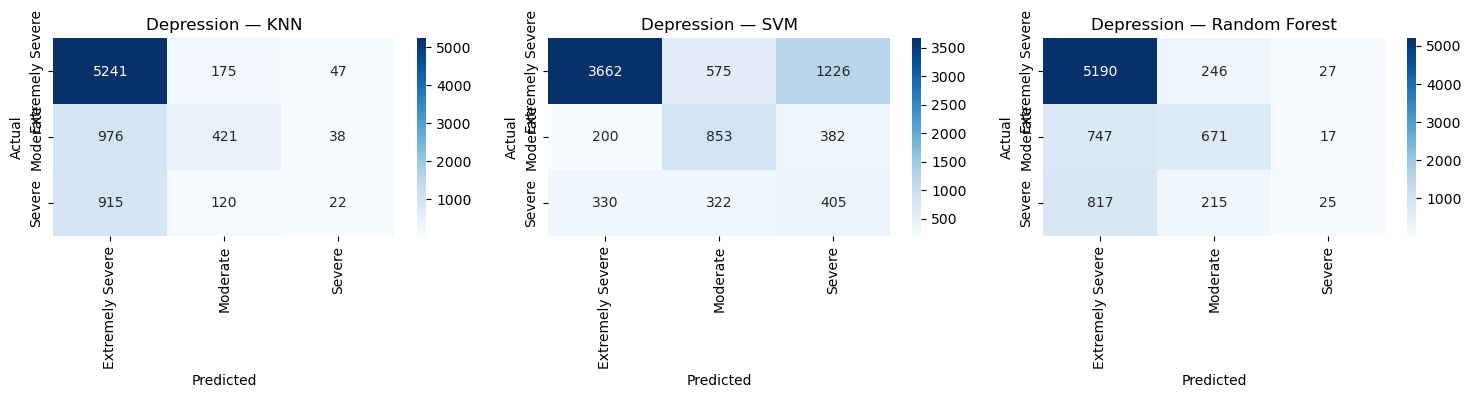

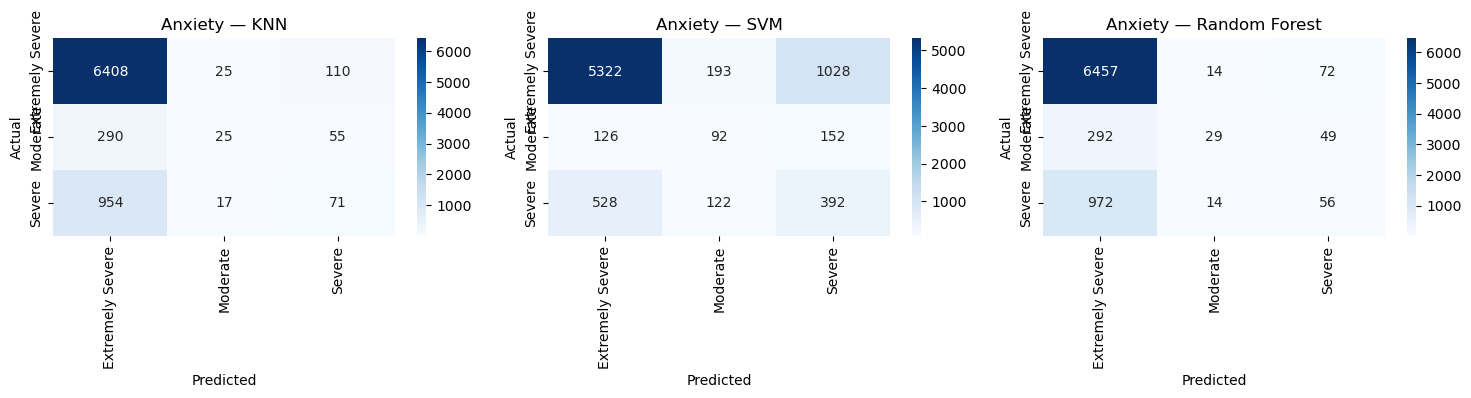

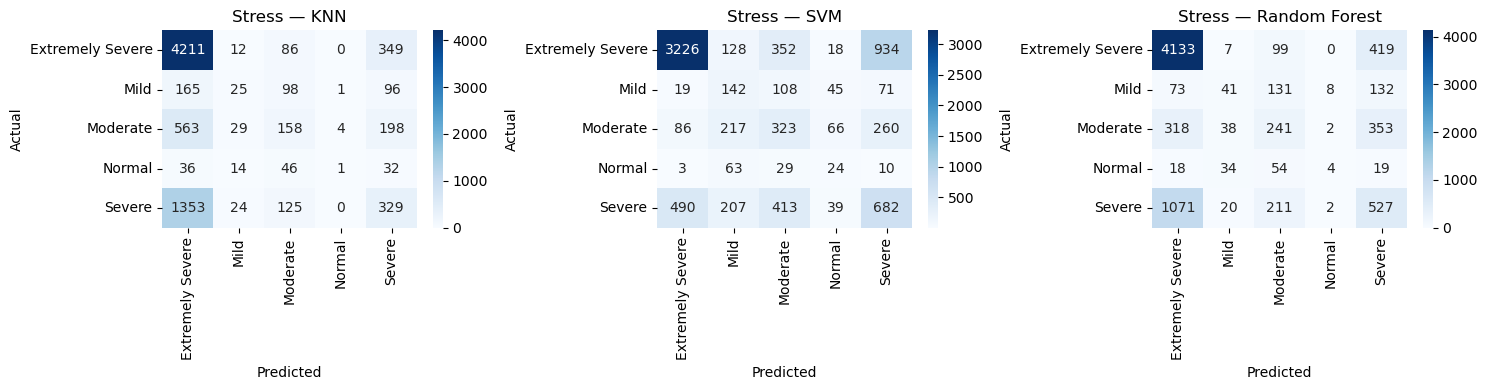

In [8]:
# Confusion matrices for the demographic-feature models
for scale_name, (preds, y_test_s, le) in demo_preds.items():
    plot_confusion_matrices(preds, y_test_s, le, title_prefix=scale_name.capitalize())


In [9]:
from sklearn.dummy import DummyClassifier

baseline_results = []
for scale_name in SCALE_ITEMS:
    y_labels = build_label(df, scale_name)
    le = LabelEncoder()
    y_enc = le.fit_transform(y_labels)
    _, X_test, _, y_test = train_test_split(
        df[DEMOGRAPHIC_FEATURES], y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
    )
    dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
    dummy.fit(X_test, y_test)  # fitting on test is fine here, DummyClassifier ignores X entirely
    dummy_pred = dummy.predict(X_test)
    baseline_results.append({
        "Scale": scale_name,
        "Baseline Accuracy": accuracy_score(y_test, dummy_pred),
        "Baseline F1 (weighted)": f1_score(y_test, dummy_pred, average="weighted", zero_division=0),
    })

pd.DataFrame(baseline_results)


,Scale,Baseline Accuracy,Baseline F1 (weighted)
0,depression,0.686738,0.559196
1,anxiety,0.822502,0.742396
2,stress,0.585544,0.432484


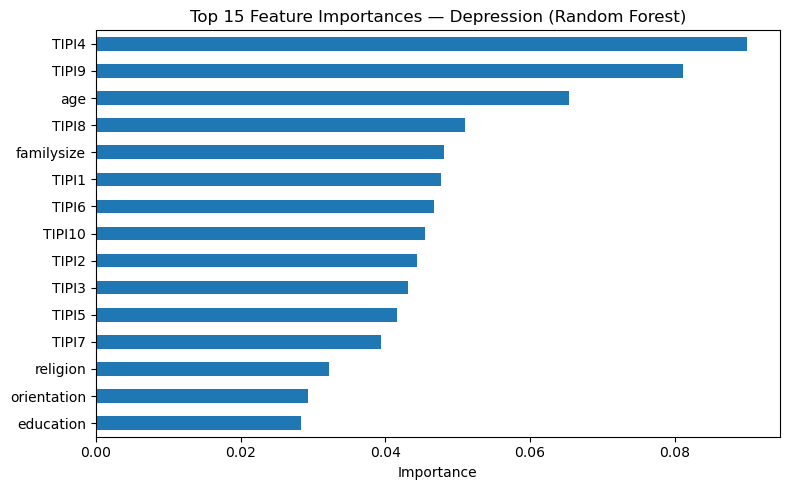

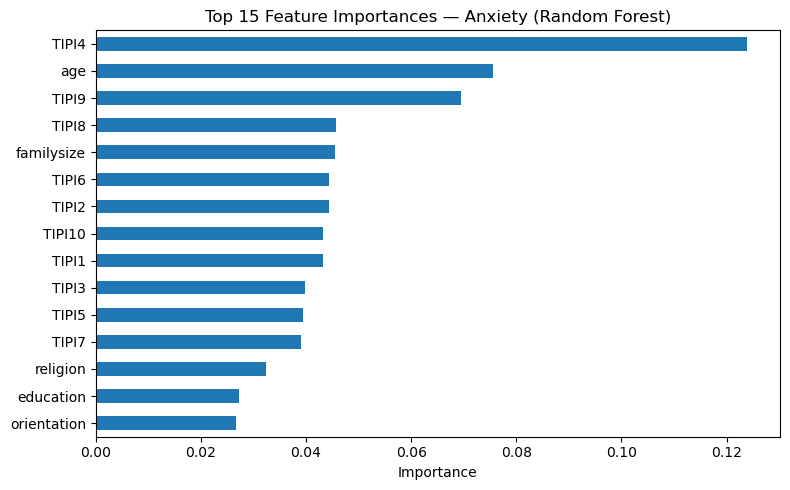

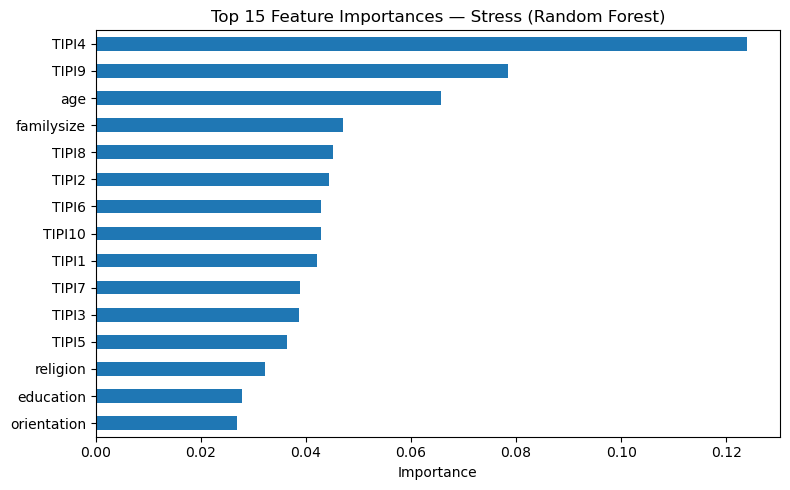

In [10]:
for scale_name, fitted in demo_fitted.items():
    rf_model = fitted["Random Forest"]
    importances = pd.Series(rf_model.feature_importances_, index=DEMOGRAPHIC_FEATURES)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Importances — {scale_name.capitalize()} (Random Forest)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


In [11]:
summary_rows = []
for scale_name in SCALE_ITEMS:
    item_best = item_results[scale_name].loc[item_results[scale_name]["F1-score"].idxmax()]
    demo_best = demo_results[scale_name].loc[demo_results[scale_name]["F1-score"].idxmax()]
    summary_rows.append({
        "Scale": scale_name,
        "Track A best model": item_best["Model"],
        "Track A F1 (inflated)": round(item_best["F1-score"], 3),
        "Track B best model": demo_best["Model"],
        "Track B F1 (realistic)": round(demo_best["F1-score"], 3),
    })

pd.DataFrame(summary_rows)


,Scale,Track A best model,Track A F1 (inflated),Track B best model,Track B F1 (realistic)
0,depression,SVM,1.000,Random Forest,0.684
1,anxiety,SVM,1.000,Random Forest,0.763
2,stress,SVM,0.999,Random Forest,0.588


In [12]:
df_sleep = pd.read_csv("../data/raw/SaYoPillow.csv")
df_sleep.info()

X_sleep = df_sleep.drop(columns=["sl"])
y_sleep = df_sleep["sl"]

metrics_sleep, fitted_sleep, preds_sleep, (X_test_sl, y_test_sl), le_sleep = train_and_evaluate(
    X_sleep, y_sleep, label_name="sleep_stress", tune=True
)
metrics_sleep


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sr      630 non-null    float64
 1   rr      630 non-null    float64
 2   t       630 non-null    float64
 3   lm      630 non-null    float64
 4   bo      630 non-null    float64
 5   rem     630 non-null    float64
 6   sr.1    630 non-null    float64
 7   hr      630 non-null    float64
 8   sl      630 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 44.4 KB
[sleep_stress] KNN best params: {'n_neighbors': 3}
[sleep_stress] SVM best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
[sleep_stress] Random Forest best params: {'max_depth': None, 'n_estimators': 200}


,Model,Accuracy,Precision,Recall,F1-score,CV F1 (mean),CV F1 (std)
0,KNN,1.00000,1.000000,1.00000,1.000000,1.0,0.0
1,SVM,1.00000,1.000000,1.00000,1.000000,1.0,0.0
2,Random Forest,0.97619,0.976484,0.97619,0.976184,1.0,0.0


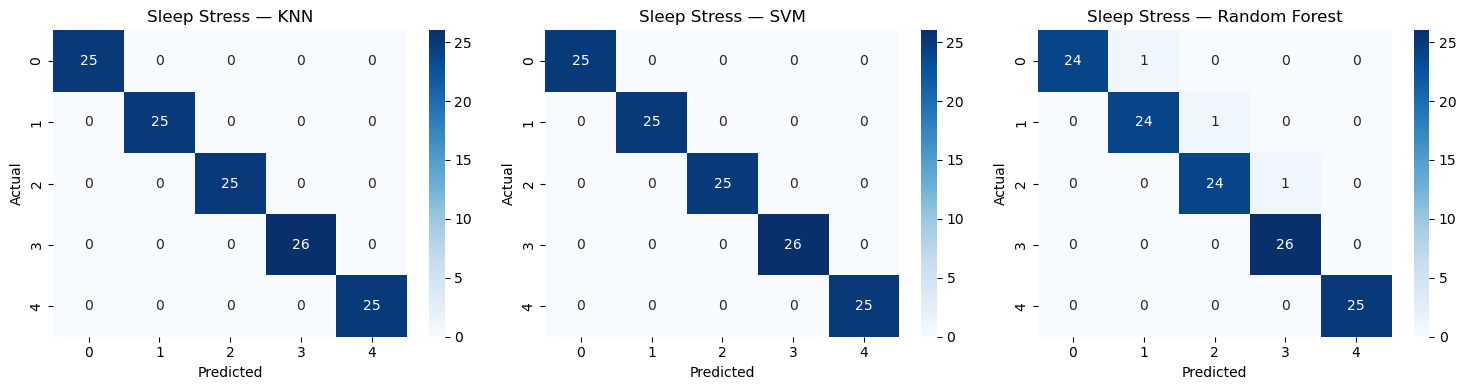

In [13]:
plot_confusion_matrices(preds_sleep, y_test_sl, le_sleep, title_prefix="Sleep Stress")


In [14]:
import os
os.makedirs("../models", exist_ok=True)

for scale_name, fitted in demo_fitted.items():
    best_name = demo_results[scale_name].loc[demo_results[scale_name]["F1-score"].idxmax(), "Model"]
    joblib.dump(fitted[best_name], f"../models/{scale_name}_best_model.joblib")
    print(f"Saved {scale_name} best model: {best_name}")


Saved depression best model: Random Forest
Saved anxiety best model: Random Forest
Saved stress best model: Random Forest
